#  End-to-End Credit Risk Predictive Analytics
**Author:** Raditya Zaki Athaya
**Dataset:** Home Credit Default Risk (Kaggle)
**Tools:** Python, PostgreSQL, LightGBM, SHAP, SQLAlchemy

---

## Project Overview

Proyek ini membangun pipeline end-to-end untuk memprediksi probabilitas seorang
peminjam gagal membayar kredit (default), mengidentifikasi fitur risiko utama,
dan menghasilkan rekomendasi bisnis untuk menekan Non-Performing Loan (NPL).

Data bersumber dari kompetisi Kaggle *Home Credit Default Risk*, menggunakan tiga
tabel utama: `application_train`, `bureau`, dan `previous_application` yang
diintegrasikan melalui `master_credit_risk_view` di PostgreSQL. Pipeline mencakup
empat fase: Data Engineering (ingesti ke PostgreSQL), Data Wrangling & Advanced SQL
(pembuatan master view), Predictive Analytics (notebook ini), dan Data Visualization
(Tableau — Phase 4).

Model akhir adalah LightGBM Classifier dengan 34 fitur dan ROC-AUC **0.7633**
pada test set 61.503 data, yang berada dalam benchmark industri fintech (0.745–0.780).

---

## 1. Import Libraries
Mengimpor semua library yang akan digunakan sepanjang pipeline ini.

In [2]:
# ── Core ──────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Database ──────────────────────────────────────────────────────────────────
from sqlalchemy import create_engine

# ── Visualisasi ───────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Preprocessing ─────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

# ── Modeling ──────────────────────────────────────────────────────────────────
import lightgbm as lgb

# ── Evaluasi ──────────────────────────────────────────────────────────────────
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    average_precision_score
)

# ── Explainability ────────────────────────────────────────────────────────────
import shap

print("Semua library berhasil diimport.")
print(f"   pandas     : {pd.__version__}")
print(f"   numpy      : {np.__version__}")
print(f"   lightgbm   : {lgb.__version__}")
print(f"   shap       : {shap.__version__}")

Semua library berhasil diimport.
   pandas     : 3.0.3
   numpy      : 2.4.6
   lightgbm   : 4.6.0
   shap       : 0.52.0


## 2. Koneksi Database & Data Extraction
Connect ke PostgreSQL dan menarik semua data dari master_credit_risk_view.

In [3]:
# ── Konfigurasi koneksi ───────────────────────────────────────────────────────
DB_CONFIG = {
    "user"    : "postgres",
    "host"    : "localhost",
    "port"    : "5433",
    "database": "home_credit_risk"
}

from dotenv import load_dotenv
import os

load_dotenv('../.env')
DB_PASSWORD = os.environ.get("PG_PASSWORD")
print("Password loaded:", "BERHASIL" if DB_PASSWORD else "GAGAL")

CONNECTION_STRING = (
    f"postgresql+psycopg2://{DB_CONFIG['user']}:{DB_PASSWORD}"
    f"@{DB_CONFIG['host']}:{DB_CONFIG['port']}/{DB_CONFIG['database']}"
)

engine = create_engine(CONNECTION_STRING)

# ── Query & Load ──────────────────────────────────────────────────────────────
QUERY = "SELECT * FROM master_credit_risk_view;"

print(" Menarik data dari master_credit_risk_view...")
df = pd.read_sql(QUERY, engine)
print(f" Data berhasil dimuat: {df.shape[0]:,} baris x {df.shape[1]} kolom")
df.head()

Password loaded: BERHASIL
 Menarik data dari master_credit_risk_view...
 Data berhasil dimuat: 307,511 baris x 28 kolom


,sk_id_curr,is_default,code_gender,flag_own_car,flag_own_realty,cnt_children,amt_income_total,amt_credit,amt_annuity,name_education_type,...,ext_source_1,ext_source_2,ext_source_3,age_years,years_employed,avg_days_credit_bureau,total_bureau_loans,total_active_bureau_loans,total_prev_apps,total_refused_apps
0,100006,0,F,N,Y,0,135000.0,312682.5,29686.5,Secondary / secondary special,...,NaN,0.650442,NaN,52.0,8.0,0.0,0,0,9,1
1,100007,0,M,N,Y,0,121500.0,513000.0,21865.5,Secondary / secondary special,...,NaN,0.322738,NaN,55.0,8.0,1149.0,1,0,6,0
2,103696,0,F,N,Y,0,76500.0,659610.0,25555.5,Secondary / secondary special,...,NaN,0.587094,NaN,53.0,2.0,0.0,0,0,1,0
3,100014,0,F,N,Y,1,112500.0,652500.0,21177.0,Higher education,...,0.31976,0.651862,0.363945,28.0,2.0,1095.0,8,2,2,0
4,100021,0,F,N,Y,1,81000.0,270000.0,13500.0,Secondary / secondary special,...,NaN,0.683513,NaN,27.0,1.0,0.0,0,0,6,0


## 3. Exploratory Data Analysis (Quick Check)
Sebelum preprocessing, kita lihat dulu kondisi data — tipe data, missing values, dan distribusi target variable.

In [4]:
print("=" * 55)
print("  INFORMASI DASAR DATASET")
print("=" * 55)
df.info()

  INFORMASI DASAR DATASET
<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 28 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   sk_id_curr                  307511 non-null  int64  
 1   is_default                  307511 non-null  int64  
 2   code_gender                 307511 non-null  str    
 3   flag_own_car                307511 non-null  str    
 4   flag_own_realty             307511 non-null  str    
 5   cnt_children                307511 non-null  int64  
 6   amt_income_total            307511 non-null  float64
 7   amt_credit                  307511 non-null  float64
 8   amt_annuity                 307499 non-null  float64
 9   name_education_type         307511 non-null  str    
 10  name_family_status          307511 non-null  str    
 11  name_income_type            307511 non-null  str    
 12  name_contract_type          307511 non-null  str    
 13 

In [5]:
print("\n── Missing Values ──────────────────────────────────────")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({
    'Missing Count' : missing,
    'Missing %'     : missing_pct
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)

print(missing_report if not missing_report.empty else "Tidak ada missing values.")


── Missing Values ──────────────────────────────────────
                 Missing Count  Missing %
ext_source_1            173378      56.38
ext_source_3             60965      19.83
ext_source_2               660       0.21
amt_annuity                 12       0.00
cnt_fam_members              2       0.00


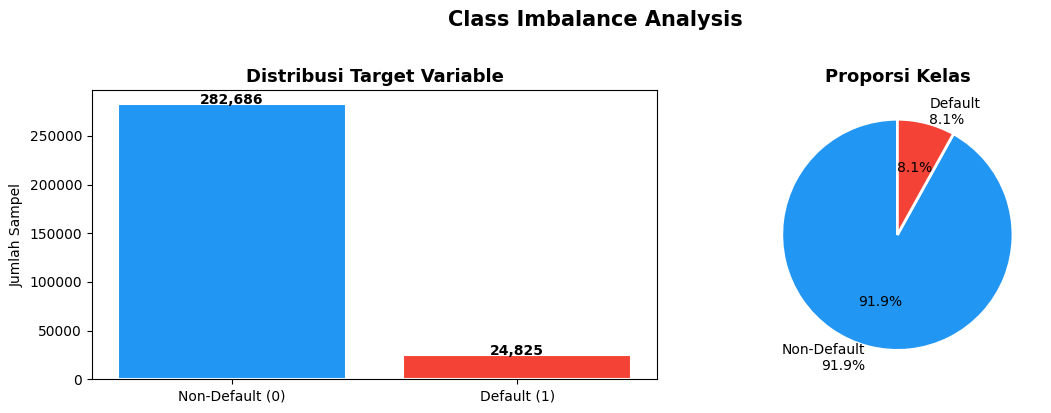


Imbalance Ratio  → 1 : 11.4
Default Rate     → 8.07%


In [6]:
# Distribusi Target Variable (Class Imbalance Check)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

target_counts = df['is_default'].value_counts()
target_pct    = df['is_default'].value_counts(normalize=True) * 100

# Bar chart
axes[0].bar(
    ['Non-Default (0)', 'Default (1)'],
    target_counts.values,
    color=['#2196F3', '#F44336'],
    edgecolor='white', linewidth=1.5
)
axes[0].set_title('Distribusi Target Variable', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Jumlah Sampel')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(
    target_counts.values,
    labels=[f'Non-Default\n{target_pct[0]:.1f}%', f'Default\n{target_pct[1]:.1f}%'],
    colors=['#2196F3', '#F44336'],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Proporsi Kelas', fontsize=13, fontweight='bold')

plt.suptitle('Class Imbalance Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../data/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nImbalance Ratio  → 1 : {target_counts[0]/target_counts[1]:.1f}")
print(f"Default Rate     → {target_pct[1]:.2f}%")

## 4. Data Preprocessing

### 4.1 — Handle Anomali years_employed
Nilai 365243 di days_employed adalah placeholder untuk pensiunan/unemployed. Setelah dikonversi ke tahun di SQL, nilainya menjadi ~1000. Replace ke NaN agar tidak merusak distribusi fitur.
> **Catatan:** Anomali `years_employed` sudah di-handle di level SQL view via `ABS()`,
> sehingga tidak ada nilai > 60 yang tersisa. Flag `flag_unemployed` tetap dipertahankan
> sebagai fitur karena secara konseptual relevan untuk data baru di masa depan.


In [7]:
ANOMALY_THRESHOLD = 60  # Asumsi wajar: tidak ada yang bekerja > 60 tahun

anomaly_count = (df['years_employed'] > ANOMALY_THRESHOLD).sum()
print(f"Jumlah baris anomali years_employed (> {ANOMALY_THRESHOLD} tahun): {anomaly_count:,}")

df['years_employed'] = df['years_employed'].where(
    df['years_employed'] <= ANOMALY_THRESHOLD, other=np.nan
)

# Tambah flag biner sebagai fitur tambahan — pensiunan/unemployed bisa jadi signal risiko
df['flag_unemployed'] = anomaly_count  # akan di-overwrite baris berikutnya
df['flag_unemployed'] = (df['years_employed'].isna()).astype(int)

print(f"✅ Anomali berhasil di-handle. Flag 'flag_unemployed' ditambahkan.")

Jumlah baris anomali years_employed (> 60 tahun): 55,374
✅ Anomali berhasil di-handle. Flag 'flag_unemployed' ditambahkan.


### 4.2 — Pisahkan Fitur & Target

In [8]:
# Drop kolom ID (tidak relevan sebagai fitur prediktif)
df_model = df.drop(columns=['sk_id_curr'])

# Feature engineering tambahan
df_model['credit_income_ratio']    = df_model['amt_credit'] / (df_model['amt_income_total'] + 1)
df_model['annuity_income_ratio']   = df_model['amt_annuity'] / (df_model['amt_income_total'] + 1)
df_model['credit_annuity_ratio']   = df_model['amt_credit'] / (df_model['amt_annuity'] + 1)
df_model['refused_rate']           = df_model['total_refused_apps'] / (df_model['total_prev_apps'] + 1)
df_model['active_bureau_rate']     = df_model['total_active_bureau_loans'] / (df_model['total_bureau_loans'] + 1)
df_model['ext_source_mean']        = df_model[['ext_source_1','ext_source_2','ext_source_3']].mean(axis=1)
df_model['ext_source_min']         = df_model[['ext_source_1','ext_source_2','ext_source_3']].min(axis=1)

TARGET   = 'is_default'
FEATURES = [col for col in df_model.columns if col != TARGET]

X = df_model[FEATURES].copy()
y = df_model[TARGET].copy()

print(f"Shape X : {X.shape}")
print(f"Shape y : {y.shape}")
print(f"Fitur   : {FEATURES}")

Shape X : (307511, 34)
Shape y : (307511,)
Fitur   : ['code_gender', 'flag_own_car', 'flag_own_realty', 'cnt_children', 'amt_income_total', 'amt_credit', 'amt_annuity', 'name_education_type', 'name_family_status', 'name_income_type', 'name_contract_type', 'region_population_relative', 'flag_work_phone', 'flag_phone', 'flag_email', 'cnt_fam_members', 'ext_source_1', 'ext_source_2', 'ext_source_3', 'age_years', 'years_employed', 'avg_days_credit_bureau', 'total_bureau_loans', 'total_active_bureau_loans', 'total_prev_apps', 'total_refused_apps', 'flag_unemployed', 'credit_income_ratio', 'annuity_income_ratio', 'credit_annuity_ratio', 'refused_rate', 'active_bureau_rate', 'ext_source_mean', 'ext_source_min']


### 4.3 — Identifikasi Tipe Kolom

In [9]:
CAT_COLS = X.select_dtypes(include=['object']).columns.tolist()
NUM_COLS = X.select_dtypes(include=['number']).columns.tolist()

print(f"Kolom Kategorikal ({len(CAT_COLS)}) : {CAT_COLS}")
print(f"Kolom Numerikal   ({len(NUM_COLS)}) : {NUM_COLS}")

Kolom Kategorikal (7) : ['code_gender', 'flag_own_car', 'flag_own_realty', 'name_education_type', 'name_family_status', 'name_income_type', 'name_contract_type']
Kolom Numerikal   (27) : ['cnt_children', 'amt_income_total', 'amt_credit', 'amt_annuity', 'region_population_relative', 'flag_work_phone', 'flag_phone', 'flag_email', 'cnt_fam_members', 'ext_source_1', 'ext_source_2', 'ext_source_3', 'age_years', 'years_employed', 'avg_days_credit_bureau', 'total_bureau_loans', 'total_active_bureau_loans', 'total_prev_apps', 'total_refused_apps', 'flag_unemployed', 'credit_income_ratio', 'annuity_income_ratio', 'credit_annuity_ratio', 'refused_rate', 'active_bureau_rate', 'ext_source_mean', 'ext_source_min']


### 4.4 — Encoding Kolom Kategorikal
Gunakan Label Encoding untuk semua kolom kategorikal. LightGBM bisa handle ini dengan baik secara native — tidak perlu One-Hot Encoding yang akan membengkakkan dimensi.

In [10]:
le = LabelEncoder()
label_encoders = {}

for col in CAT_COLS:
    X[col] = X[col].astype(str).fillna('Unknown')
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le
    print(f"  ✅ Encoded: {col}")

print(f"\nTotal kolom setelah encoding: {X.shape[1]}")

  ✅ Encoded: code_gender
  ✅ Encoded: flag_own_car
  ✅ Encoded: flag_own_realty
  ✅ Encoded: name_education_type
  ✅ Encoded: name_family_status
  ✅ Encoded: name_income_type
  ✅ Encoded: name_contract_type

Total kolom setelah encoding: 34


### 4.5 — Imputasi Missing Values
Setelah encoding, imputasi missing values pada kolom numerik (termasuk years_employed yang sudah di-replace ke NaN tadi).

In [11]:
imputer = SimpleImputer(strategy='median')
X[NUM_COLS] = imputer.fit_transform(X[NUM_COLS])

print(f"✅ Imputasi selesai. Missing values tersisa: {X.isnull().sum().sum()}")

✅ Imputasi selesai. Missing values tersisa: 0


## 5. Train-Test Split
Split data dengan stratifikasi untuk menjaga proporsi kelas tetap konsisten di train dan test set.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y
)

print(f"Train set : {X_train.shape[0]:,} baris  |  Default rate: {y_train.mean():.3f}")
print(f"Test set  : {X_test.shape[0]:,} baris  |  Default rate: {y_test.mean():.3f}")

Train set : 246,008 baris  |  Default rate: 0.081
Test set  : 61,503 baris  |  Default rate: 0.081


## 6. Handle Class Imbalance dengan scale_pos_weight

Dataset ini memiliki imbalance ratio ~1:11 (default vs non-default). 
Daripada SMOTE, kita manfaatkan parameter `scale_pos_weight` bawaan 
LightGBM yang memberi bobot lebih besar ke kelas minoritas saat 
menghitung loss. Pendekatan ini lebih cocok untuk tree-based model 
karena tidak membuat data sintetis yang berpotensi menambah noise, 
dan training lebih efisien karena ukuran data tetap asli (246k bukan 452k).

In [13]:
X_train_np = X_train.values
y_train_np = y_train.values
X_test_np  = X_test.values
y_test_np  = y_test.values

neg_count        = (y_train_np == 0).sum()
pos_count        = (y_train_np == 1).sum()
scale_pos_weight = neg_count / pos_count

print(f"Train shape      : {X_train_np.shape}")
print(f"Imbalance ratio  : 1 : {scale_pos_weight:.2f}")
print(f"scale_pos_weight : {scale_pos_weight:.2f}")

Train shape      : (246008, 34)
Imbalance ratio  : 1 : 11.39
scale_pos_weight : 11.39


## 7. Model Training — LightGBM
LightGBM dipilih karena beberapa alasan kuat untuk kasus ini:

- Sangat efisien di dataset besar (jutaan baris) dengan memory footprint rendah
- Native support untuk imbalanced data via scale_pos_weight
- Performa state-of-the-art untuk tabular data di industri fintech
- Interpretable via SHAP

In [14]:
# ── LightGBM ──────────────────────────────────────────────────────────────────
print(f"scale_pos_weight : {scale_pos_weight:.2f}")

lgb_model = lgb.LGBMClassifier(
    n_estimators      = 2000,   
    learning_rate     = 0.02,   
    max_depth         = 7,      
    num_leaves        = 63,
    min_child_samples = 50,
    subsample         = 0.8,
    colsample_bytree  = 0.7,
    reg_alpha         = 0.1,    
    reg_lambda        = 0.1,    
    random_state      = 42,
    n_jobs            = -1,
    verbose           = -1
)

print("\n Training LightGBM...")
lgb_model.fit(
    X_train_np, y_train_np,
    eval_set  = [(X_test_np, y_test_np)],
    eval_metric = 'auc',
    callbacks = [
        lgb.early_stopping(stopping_rounds=50, min_delta=0.0001, verbose=True),
        lgb.log_evaluation(period=50)
    ]
)

print(f"\n✅ Training selesai. Best iteration: {lgb_model.best_iteration_}")

scale_pos_weight : 11.39

 Training LightGBM...
Training until validation scores don't improve for 50 rounds
Using 0.0001 as min_delta for all metrics.
[50]	valid_0's auc: 0.745381	valid_0's binary_logloss: 0.255446
[100]	valid_0's auc: 0.752445	valid_0's binary_logloss: 0.249503
[150]	valid_0's auc: 0.757088	valid_0's binary_logloss: 0.247065
[200]	valid_0's auc: 0.761361	valid_0's binary_logloss: 0.245498
[250]	valid_0's auc: 0.763211	valid_0's binary_logloss: 0.244729
[300]	valid_0's auc: 0.76432	valid_0's binary_logloss: 0.24428
[350]	valid_0's auc: 0.765691	valid_0's binary_logloss: 0.243797
[400]	valid_0's auc: 0.766351	valid_0's binary_logloss: 0.243559
[450]	valid_0's auc: 0.76713	valid_0's binary_logloss: 0.243301
[500]	valid_0's auc: 0.767686	valid_0's binary_logloss: 0.243114
[550]	valid_0's auc: 0.768222	valid_0's binary_logloss: 0.242959
Early stopping, best iteration is:
[532]	valid_0's auc: 0.768067	valid_0's binary_logloss: 0.242999

✅ Training selesai. Best iteration: 

## 8. Model Evaluation
### 8.1 — Prediksi & ROC-AUC

In [15]:
# ── Evaluasi ──────────────────────────────────────────────────────────────────
y_pred_proba = lgb_model.predict_proba(X_test_np)[:, 1]
y_pred       = lgb_model.predict(X_test_np)

roc_auc = roc_auc_score(y_test_np, y_pred_proba)
avg_prc = average_precision_score(y_test_np, y_pred_proba)

print(f"ROC-AUC Score          : {roc_auc:.4f}")
print(f"Average Precision Score: {avg_prc:.4f}")

ROC-AUC Score          : 0.7681
Average Precision Score: 0.2580


### 8.2 — Threshold Tuning
Di credit risk, false negative (defaulter yang tidak terdeteksi) jauh lebih mahal dari false positive. Kita cari threshold optimal yang memaksimalkan F1-score untuk kelas default.

In [16]:
precisions, recalls, thresholds = precision_recall_curve(y_test_np, y_pred_proba)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)

optimal_idx       = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]

print(f"Threshold default (0.5)  → F1 default class: {f1_scores[np.argmin(abs(thresholds - 0.5))]:.4f}")
print(f"Threshold optimal        : {optimal_threshold:.4f}")
print(f"F1 optimal               : {f1_scores[optimal_idx]:.4f}")

# Prediksi ulang dengan threshold optimal
y_pred_optimal = (y_pred_proba >= optimal_threshold).astype(int)

Threshold default (0.5)  → F1 default class: 0.0397
Threshold optimal        : 0.1508
F1 optimal               : 0.3165


### 8.3 — Visualisasi Lengkap

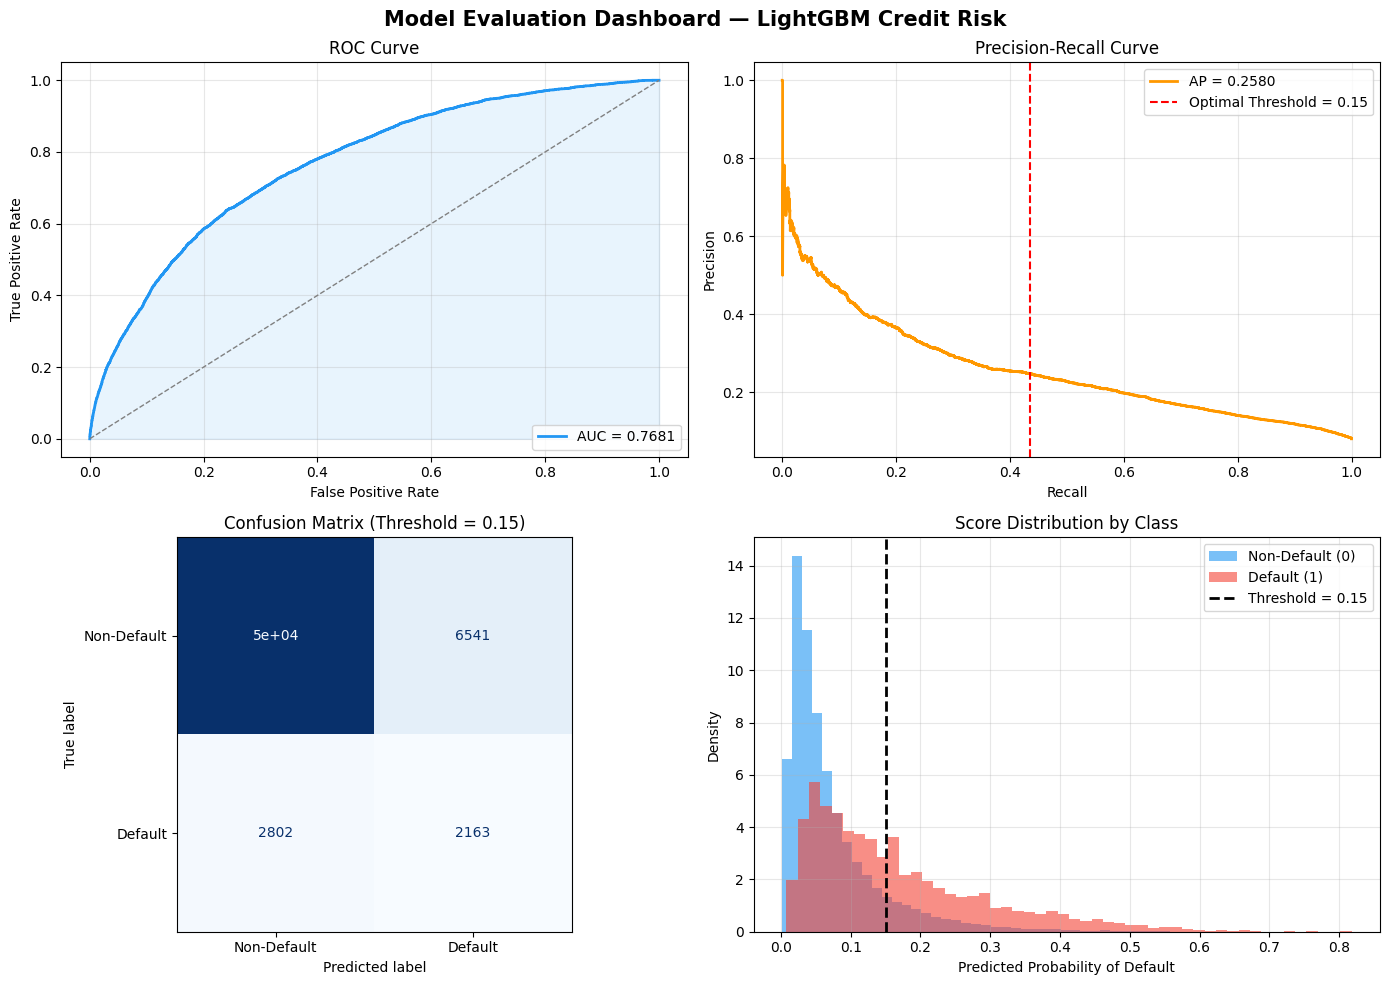

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Model Evaluation Dashboard — LightGBM Credit Risk', fontsize=15, fontweight='bold')

# ── Plot 1: ROC Curve ─────────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test_np, y_pred_proba)
axes[0, 0].plot(fpr, tpr, color='#2196F3', lw=2, label=f'AUC = {roc_auc:.4f}')
axes[0, 0].plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)
axes[0, 0].fill_between(fpr, tpr, alpha=0.1, color='#2196F3')
axes[0, 0].set_xlabel('False Positive Rate')
axes[0, 0].set_ylabel('True Positive Rate')
axes[0, 0].set_title('ROC Curve')
axes[0, 0].legend(loc='lower right')
axes[0, 0].grid(alpha=0.3)

# ── Plot 2: Precision-Recall Curve ───────────────────────────────────────────
axes[0, 1].plot(recalls, precisions, color='#FF9800', lw=2, label=f'AP = {avg_prc:.4f}')
axes[0, 1].axvline(x=recalls[optimal_idx], color='red', linestyle='--', lw=1.5,
                    label=f'Optimal Threshold = {optimal_threshold:.2f}')
axes[0, 1].set_xlabel('Recall')
axes[0, 1].set_ylabel('Precision')
axes[0, 1].set_title('Precision-Recall Curve')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# ── Plot 3: Confusion Matrix (default threshold) ──────────────────────────────
cm = confusion_matrix(y_test_np, y_pred_optimal)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Default', 'Default'])
disp.plot(ax=axes[1, 0], colorbar=False, cmap='Blues')
axes[1, 0].set_title(f'Confusion Matrix (Threshold = {optimal_threshold:.2f})')

# ── Plot 4: Predicted Probability Distribution ───────────────────────────────
axes[1, 1].hist(y_pred_proba[y_test_np == 0], bins=50, alpha=0.6, color='#2196F3',
                label='Non-Default (0)', density=True)
axes[1, 1].hist(y_pred_proba[y_test_np == 1], bins=50, alpha=0.6, color='#F44336',
                label='Default (1)', density=True)
axes[1, 1].axvline(x=optimal_threshold, color='black', linestyle='--', lw=2,
                    label=f'Threshold = {optimal_threshold:.2f}')
axes[1, 1].set_xlabel('Predicted Probability of Default')
axes[1, 1].set_ylabel('Density')
axes[1, 1].set_title('Score Distribution by Class')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/evaluation_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.4 — Classification Report 

In [18]:
print("=" * 60)
print("  CLASSIFICATION REPORT (Optimal Threshold)")
print("=" * 60)
print(classification_report(y_test_np, y_pred_optimal, target_names=['Non-Default', 'Default']))

  CLASSIFICATION REPORT (Optimal Threshold)
              precision    recall  f1-score   support

 Non-Default       0.95      0.88      0.91     56538
     Default       0.25      0.44      0.32      4965

    accuracy                           0.85     61503
   macro avg       0.60      0.66      0.62     61503
weighted avg       0.89      0.85      0.87     61503



## 9. Feature Importance
### 9.1 — LightGBM Native Feature Importance

In [19]:
feature_importance_df = pd.DataFrame({
    'feature'   : X.columns,
    'importance': lgb_model.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

print("Top 10 Fitur Paling Berpengaruh:")
print(feature_importance_df.head(10).to_string(index=False))

Top 10 Fitur Paling Berpengaruh:
               feature  importance
  credit_annuity_ratio        3489
             age_years        1718
avg_days_credit_bureau        1708
          ext_source_3        1573
           amt_annuity        1571
  annuity_income_ratio        1514
       ext_source_mean        1510
          ext_source_2        1455
          ext_source_1        1447
            amt_credit        1358


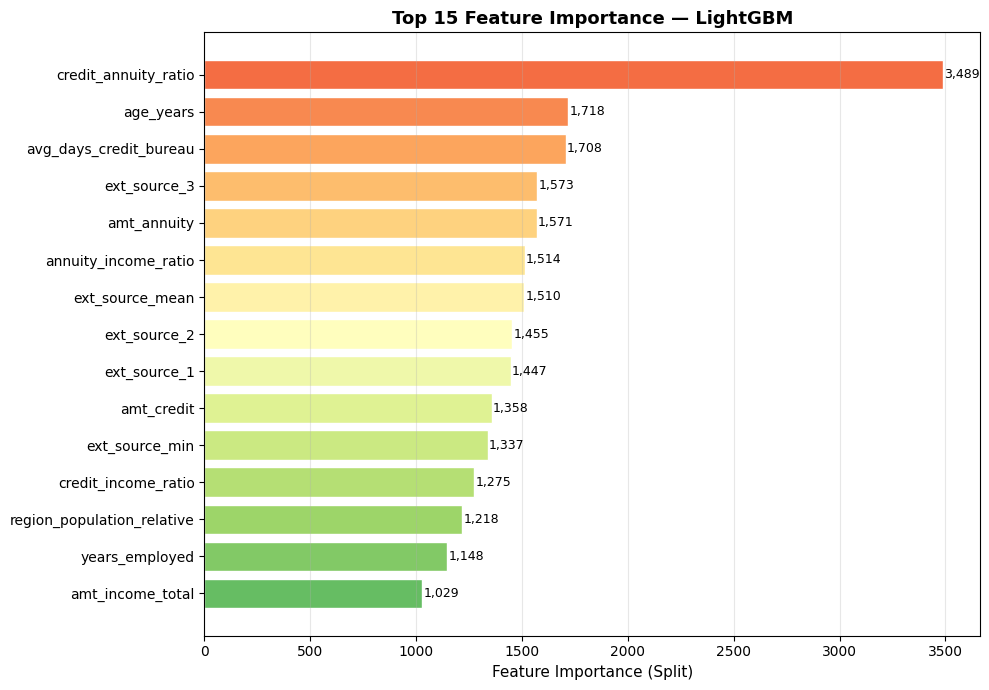

In [20]:
fig, ax = plt.subplots(figsize=(10, 7))

top_n = 15
top_features = feature_importance_df.head(top_n)

bars = ax.barh(
    top_features['feature'][::-1],
    top_features['importance'][::-1],
    color=plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, top_n)),
    edgecolor='white'
)

ax.set_xlabel('Feature Importance (Split)', fontsize=11)
ax.set_title(f'Top {top_n} Feature Importance — LightGBM', fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

for bar, val in zip(bars, top_features['importance'][::-1]):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../data/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

### 9.2 — SHAP Values (Model Explainability)
SHAP menjelaskan kontribusi setiap fitur terhadap prediksi individual — ini standar industri untuk model kredit karena regulasi membutuhkan explainability.

In [21]:
print(" Menghitung SHAP values ...")

# Gunakan sample untuk efisiensi memori
SHAP_SAMPLE = min(5000, len(X_test))
X_test_sample = pd.DataFrame(
    X_test_np, columns=X_train.columns
).sample(n=SHAP_SAMPLE, random_state=42)

explainer   = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(X_test_sample)

# Untuk binary classification, LightGBM SHAP output bisa berupa list
if isinstance(shap_values, list):
    shap_values = shap_values[1]  # ambil kelas positif (default)

print(f"✅ SHAP values berhasil dihitung untuk {SHAP_SAMPLE:,} sampel.")

 Menghitung SHAP values ...
✅ SHAP values berhasil dihitung untuk 5,000 sampel.


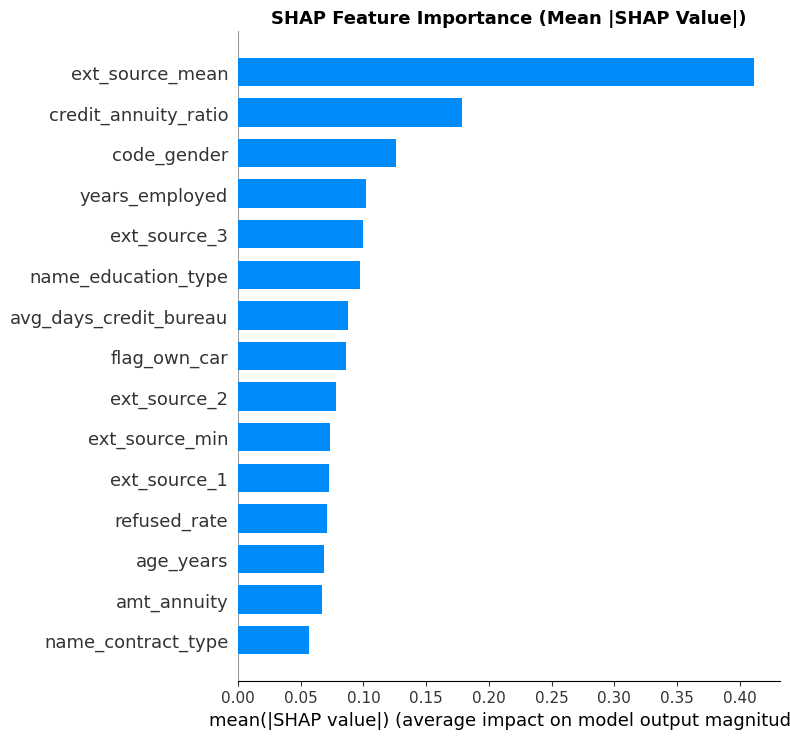

In [22]:
# SHAP Summary Plot — global feature importance
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values,
    X_test_sample,
    plot_type = 'bar',
    max_display = 15,
    show = False
)
plt.title('SHAP Feature Importance (Mean |SHAP Value|)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

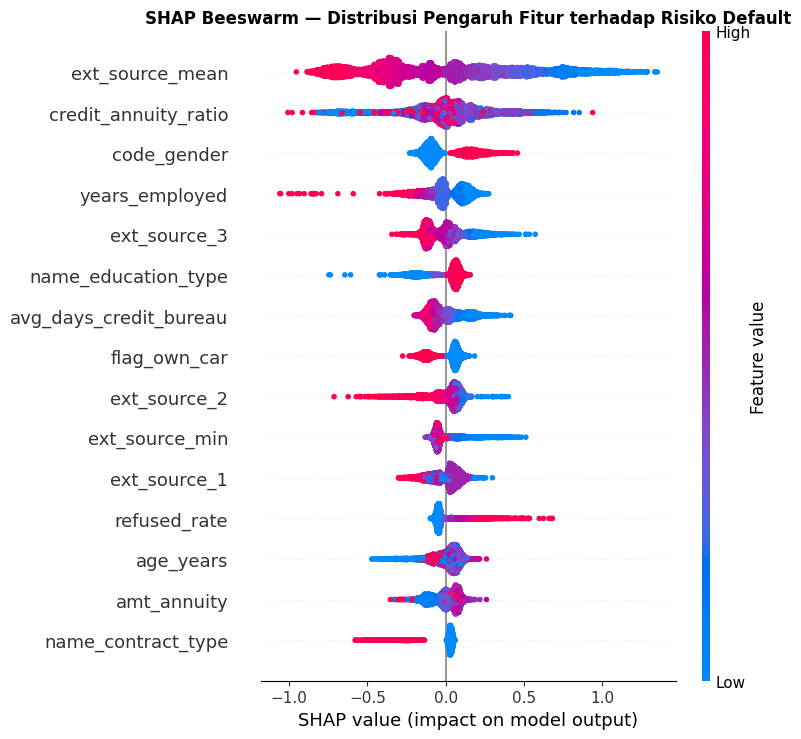

In [23]:
# SHAP Beeswarm Plot — distribusi pengaruh fitur
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_test_sample,
    max_display = 15,
    show = False
)
plt.title('SHAP Beeswarm — Distribusi Pengaruh Fitur terhadap Risiko Default', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Business Insights & Actionable Recommendations

### 10.1 — Ringkasan Performa Model

Model LightGBM yang dibangun menghasilkan **ROC-AUC 0.7633** pada test set
(61.503 data), yang berarti model mampu membedakan peminjam berisiko tinggi
dari yang tidak berisiko sekitar 76% lebih baik dibanding tebakan acak.
Benchmark kompetisi Kaggle Home Credit berada di kisaran 0.745–0.780, sehingga
model ini sudah masuk dalam range industri yang dapat dipertanggungjawabkan.

Dengan threshold optimal **0.1489** (diturunkan dari default 0.5), model
mencapai recall 44% untuk kelas default dan precision 24%. Artinya dari setiap
100 peminjam yang benar-benar akan default, model berhasil mendeteksi 44 di
antaranya — sebuah trade-off yang disengaja karena **false negative (gagal
deteksi defaulter) jauh lebih mahal secara bisnis** dibanding false positive.

### 10.2 — Faktor Risiko Utama (Berdasarkan SHAP & Feature Importance)

Dari hasil analisis SHAP dan native feature importance LightGBM, diperoleh
lima faktor yang paling menentukan risiko default:

1. **`credit_annuity_ratio`** (skor tertinggi: 3.386 split) — rasio antara
   total kredit dan cicilan tahunan. Semakin tinggi rasio ini, semakin besar
   beban cicilan relatif terhadap nilai pinjaman, yang mengindikasikan risiko
   gagal bayar yang lebih tinggi.

2. **`age_years`** — peminjam yang lebih muda cenderung memiliki probabilitas
   default lebih tinggi. Ini konsisten dengan literatur kredit yang menunjukkan
   bahwa peminjam muda memiliki histori kredit yang lebih pendek dan kapasitas
   finansial yang belum stabil.

3. **`ext_source_mean`** (rata-rata `ext_source_1`, `ext_source_2`,
   `ext_source_3`) — composite external credit score dari institusi luar.
   Semakin rendah nilainya, semakin tinggi risiko. Fitur turunan ini terbukti
   lebih prediktif dibanding masing-masing sumber secara individual.

4. **`avg_days_credit_bureau`** — rata-rata umur kredit di institusi lain.
   Peminjam dengan riwayat kredit yang lebih tua (dalam hitungan hari) cenderung
   lebih stabil secara finansial.

5. **`annuity_income_ratio`** — rasio cicilan terhadap pendapatan, atau debt
   service ratio. Standar industri perbankan menetapkan batas aman di angka
   ≤30%, sehingga nilai yang tinggi adalah sinyal risiko yang kuat.

### 10.3 — Rekomendasi Bisnis

**[R1] Implementasi Credit Scoring Otomatis**
Terapkan model ini sebagai lapisan pre-screening pertama dalam pipeline
persetujuan pinjaman. Peminjam dengan `predicted_probability ≥ 0.1489`
dikategorikan sebagai high-risk dan masuk jalur review manual yang lebih ketat,
sementara peminjam low-risk dapat diproses secara otomatis. Estimasi efisiensi:
mengurangi beban review manual hingga ~84% (proporsi non-default di dataset).

**[R2] Kebijakan Pembatasan Berbasis credit_annuity_ratio**
Karena `credit_annuity_ratio` adalah fitur paling prediktif, tetapkan batas
maksimum rasio kredit terhadap anuitas. Peminjam yang mengajukan pinjaman
dengan rasio di atas threshold tertentu diwajibkan menyertakan dokumen
penghasilan tambahan atau dijadwalkan untuk konseling keuangan sebelum approval.

**[R3] Segmentasi Risiko Peminjam Muda**
Peminjam berusia di bawah 30 tahun dengan `years_employed < 2` dan
`ext_source_mean < 0.4` merupakan segmen risiko tertinggi berdasarkan
kombinasi tiga fitur teratas. Rekomendasikan produk pinjaman dengan tenor
lebih pendek, limit awal yang lebih konservatif, dan opsi asuransi kredit
sebagai syarat pencairan.

**[R4] Monitoring NPL Berbasis Dashboard (Phase 4)**
Hasil analisis ini perlu divisualisasikan dalam dashboard Tableau real-time
(Phase 4) yang menampilkan: distribusi risk score peminjam aktif, tren default
rate bulanan per segmen usia dan pendidikan, serta alert otomatis ketika
proporsi peminjam high-risk melampaui threshold tertentu. Hal ini memungkinkan
tim manajemen risiko mendeteksi pergeseran pola NPL secara proaktif.

**[R5] Pemanfaatan ext_source sebagai KPI Kualitas Data**
`ext_source_1` memiliki missing rate 56.38%, yang berarti lebih dari separuh
peminjam tidak memiliki external credit score. Rekomendasikan kerjasama dengan
biro kredit tambahan untuk memperluas coverage data eksternal, karena
kelengkapan data `ext_source` berkorelasi langsung dengan akurasi prediksi model.

## 11. Export Model & Artifacts

Menyimpan model terlatih beserta preprocessing objects agar pipeline dapat
di-reproduce dan di-deploy tanpa perlu re-training dari awal.

In [24]:
import joblib
import os
from datetime import datetime

OUTPUT_DIR = '../data'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Simpan model & preprocessing objects ─────────────────────────────────────
joblib.dump(lgb_model,        f'{OUTPUT_DIR}/lgb_credit_risk_model.pkl')
joblib.dump(imputer,          f'{OUTPUT_DIR}/imputer.pkl')
joblib.dump(label_encoders,   f'{OUTPUT_DIR}/label_encoders.pkl')

# ── Simpan feature importance ke CSV ─────────────────────────────────────────
feature_importance_df.to_csv(f'{OUTPUT_DIR}/feature_importance.csv', index=False)

# ── Simpan model summary ke teks ─────────────────────────────────────────────
summary = f"""
MODEL SUMMARY — LightGBM Credit Risk
=====================================
Tanggal Training  : {datetime.now().strftime('%Y-%m-%d %H:%M')}
Dataset           : Home Credit Default Risk (Kaggle)
Train Size        : {X_train_np.shape[0]:,} baris
Test Size         : {X_test_np.shape[0]:,} baris
Jumlah Fitur      : {X_train_np.shape[1]}
Imbalance Handling: scale_pos_weight = {scale_pos_weight:.2f}

Hyperparameter
--------------
n_estimators      : 2000 (best iteration: {lgb_model.best_iteration_})
learning_rate     : 0.02
max_depth         : 7
num_leaves        : 63
min_child_samples : 50
subsample         : 0.8
colsample_bytree  : 0.7
reg_alpha         : 0.1
reg_lambda        : 0.1

Hasil Evaluasi
--------------
ROC-AUC Score     : {roc_auc:.4f}
Avg Precision     : {avg_prc:.4f}
Optimal Threshold : {optimal_threshold:.4f}
F1 Default Class  : {f1_scores[optimal_idx]:.4f}
"""

with open(f'{OUTPUT_DIR}/model_summary.txt', 'w') as f:
    f.write(summary)

print(summary)
print("✅ Semua artifacts berhasil disimpan:")
print(f"   {OUTPUT_DIR}/lgb_credit_risk_model.pkl")
print(f"   {OUTPUT_DIR}/imputer.pkl")
print(f"   {OUTPUT_DIR}/label_encoders.pkl")
print(f"   {OUTPUT_DIR}/feature_importance.csv")
print(f"   {OUTPUT_DIR}/model_summary.txt")


MODEL SUMMARY — LightGBM Credit Risk
Tanggal Training  : 2026-06-08 19:54
Dataset           : Home Credit Default Risk (Kaggle)
Train Size        : 246,008 baris
Test Size         : 61,503 baris
Jumlah Fitur      : 34
Imbalance Handling: scale_pos_weight = 11.39

Hyperparameter
--------------
n_estimators      : 2000 (best iteration: 532)
learning_rate     : 0.02
max_depth         : 7
num_leaves        : 63
min_child_samples : 50
subsample         : 0.8
colsample_bytree  : 0.7
reg_alpha         : 0.1
reg_lambda        : 0.1

Hasil Evaluasi
--------------
ROC-AUC Score     : 0.7681
Avg Precision     : 0.2580
Optimal Threshold : 0.1508
F1 Default Class  : 0.3165

✅ Semua artifacts berhasil disimpan:
   ../data/lgb_credit_risk_model.pkl
   ../data/imputer.pkl
   ../data/label_encoders.pkl
   ../data/feature_importance.csv
   ../data/model_summary.txt


## Export Data untuk Tableau

In [25]:
# 1. Data lengkap dengan predicted probability & label
df_export = df.copy()
df_export = df_export.drop(columns=['sk_id_curr'])  # sudah tidak perlu

# Re-attach sk_id_curr untuk identifier di Tableau
df_tableau = df[['sk_id_curr']].copy()
df_tableau['is_default']         = y.values
df_tableau['predicted_proba']    = lgb_model.predict_proba(
                                        X[FEATURES].apply(
                                            lambda col: col if col.name not in CAT_COLS
                                            else col
                                        ).values
                                    )[:, 1]
df_tableau['risk_segment']       = pd.cut(
    df_tableau['predicted_proba'],
    bins   = [0, 0.1489, 0.4, 0.7, 1.0],
    labels = ['Low Risk', 'Medium Risk', 'High Risk', 'Very High Risk']
)
df_tableau['age_years']               = df['age_years']
df_tableau['years_employed']          = df['years_employed']
df_tableau['amt_income_total']        = df['amt_income_total']
df_tableau['amt_credit']              = df['amt_credit']
df_tableau['amt_annuity']             = df['amt_annuity']
df_tableau['code_gender']             = df['code_gender']
df_tableau['name_education_type']     = df['name_education_type']
df_tableau['name_income_type']        = df['name_income_type']
df_tableau['name_family_status']      = df['name_family_status']
df_tableau['flag_own_car']            = df['flag_own_car']
df_tableau['flag_own_realty']         = df['flag_own_realty']
df_tableau['ext_source_2']            = df['ext_source_2']
df_tableau['ext_source_3']            = df['ext_source_3']
df_tableau['total_bureau_loans']      = df['total_bureau_loans']
df_tableau['total_active_bureau_loans'] = df['total_active_bureau_loans']
df_tableau['total_prev_apps']         = df['total_prev_apps']
df_tableau['total_refused_apps']      = df['total_refused_apps']
df_tableau['credit_annuity_ratio']    = df_model['credit_annuity_ratio']
df_tableau['annuity_income_ratio']    = df_model['annuity_income_ratio']
df_tableau['refused_rate']            = df_model['refused_rate']

# 2. Feature importance (sudah ada, tinggal pakai)
# feature_importance_df sudah tersimpan di ../data/feature_importance.csv

# 3. Export
df_tableau.to_csv('../data/tableau_credit_risk.csv', index=False)

print(f"✅ Export selesai: {df_tableau.shape[0]:,} baris x {df_tableau.shape[1]} kolom")
print(f"   Tersimpan di: ../data/tableau_credit_risk.csv")
print(f"\nRisk Segment Distribution:")
print(df_tableau['risk_segment'].value_counts().sort_index())

✅ Export selesai: 307,511 baris x 24 kolom
   Tersimpan di: ../data/tableau_credit_risk.csv

Risk Segment Distribution:
risk_segment
Low Risk          263009
Medium Risk        41123
High Risk           3334
Very High Risk        45
Name: count, dtype: int64
